Time Range: 2024-08-10 00:00:00 to 2024-09-30 23:30:00
Lat/Lon Box: 5.0499997 to 19.949999


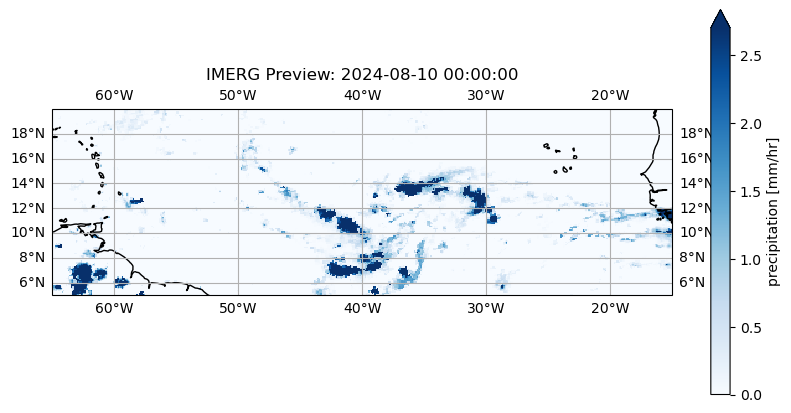

In [4]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# 1. Open the new combined file
#    (produced by satellite_preprocessing.py)
ds = xr.open_dataset("/g/data/k10/zr7147/ORCESTRA_IMERG_Combined_Cropped.nc")

# 2. Check the basics
print("Time Range:", ds.time.values[0], "to", ds.time.values[-1])
print("Lat/Lon Box:", ds.lat.min().values, "to", ds.lat.max().values)

# 3. Simple Plot of the first time step
plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
ds['precipitation'].isel(time=0).plot(
    ax=ax,
    x='lon',
    y='lat',
    transform=ccrs.PlateCarree(),
    cmap='Blues',
    robust=True,
    shading='nearest'
)
ax.coastlines()
ax.gridlines(draw_labels=True)
plt.title(f"IMERG Preview: {ds.time.values[0]}")
plt.show()


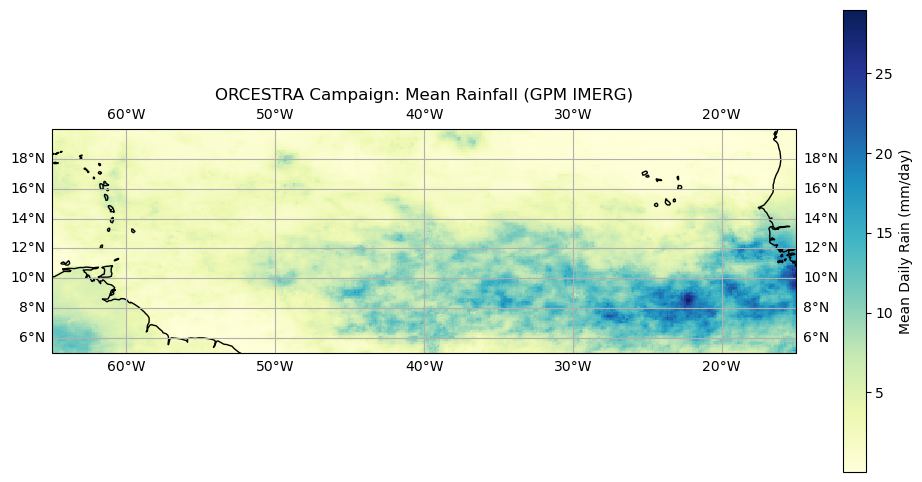

In [ ]:
# Calculate the total accumulation (mean rate) over the whole campaign
total_rain = ds['precipitation'].mean(dim='time') * 24  # Convert to mm/day

plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
total_rain.plot(
    ax=ax,
    x='lon',
    y='lat',
    transform=ccrs.PlateCarree(),
    cmap='YlGnBu',
    cbar_kwargs={'label': 'Mean Daily Rain (mm/day)'},
    shading='nearest'
)
ax.coastlines()
ax.gridlines(draw_labels=True)
plt.title("ORCESTRA Campaign: Mean Rainfall (GPM IMERG)")
plt.show()

In [4]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import numpy as np
import os

In [5]:

# --- PATHS (Update these to your Gadi paths) ---
# Dropsonde dataset (the one with 'category_evolutionary')
# ds = xr.open_dataset("/g/data/k10/zr7147/processed_dropsondes.nc") 

# New IMERG Combined file
sat_path = "/g/data/k10/zr7147/ORCESTRA_IMERG_Combined_Cropped.nc"
ds_gpm = xr.open_dataset(sat_path)

print(f"Datasets Loaded. Campaign Range: {ds_gpm.time.values[0]} to {ds_gpm.time.values[-1]}")

Datasets Loaded. Campaign Range: 2024-08-10 00:00:00 to 2024-09-30 23:30:00


---
## Sounding + Satellite Side-by-Side Comparison
Load pre-categorized dropsonde data (saved from `new_categorisation-omega.ipynb`) and match each sounding to the IMERG satellite snapshot at the time of the drop.

> **Why load from saved Zarr?**  The categorisation loop takes ~4 min each run. Loading the saved output keeps this notebook fast and focused on plotting only.

In [6]:
# ─── Load pre-categorized sounding data from saved Zarr ───────────────────────
# Why Zarr not NetCDF? xarray + netCDF4 cannot write numpy 2.0 StringDType
# (a known bug). The categorisation notebook saved to Zarr which handles all
# string dtypes natively. Load here in seconds instead of re-running the 4-min loop.

ds_sonde = xr.open_zarr("/g/data/k10/zr7147/ORCESTRA_dropsondes_categorized.zarr")

# Category labels were saved as a CSV (joined on 'circle')
df_cats = pd.read_csv("/g/data/k10/zr7147/ORCESTRA_dropsondes_categories.csv")

# Decode circle times to pandas Timestamps for matching against IMERG
circle_times = pd.to_datetime(ds_sonde['circle_time'].values)

print(f"Soundings:  {ds_sonde.dims['circle']} circles")
print(f"Categories: {len(df_cats)} rows")
print(f"IMERG:      {ds_gpm.time.values[0]} → {ds_gpm.time.values[-1]}")
print("\nCategory counts (evolutionary method):")
print(df_cats['category_evolutionary'].value_counts(dropna=False).to_string())


Soundings:  89 circles
Categories: 89 rows
IMERG:      2024-08-10 00:00:00 → 2024-09-30 23:30:00

Category counts (evolutionary method):
category_evolutionary
Bottom-Heavy                      26
Inactive / Suppressed             25
Top-Heavy                         19
Bottom-Heavy (Fully Ascending)     9
Top-Heavy (Fully Ascending)        8
Missing Data                       2


/scratch/nf33/zr7147/tmp/ipykernel_58971/3725969904.py:14: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Soundings:  {ds_sonde.dims['circle']} circles")


Generating 62 omega-satellite figures...


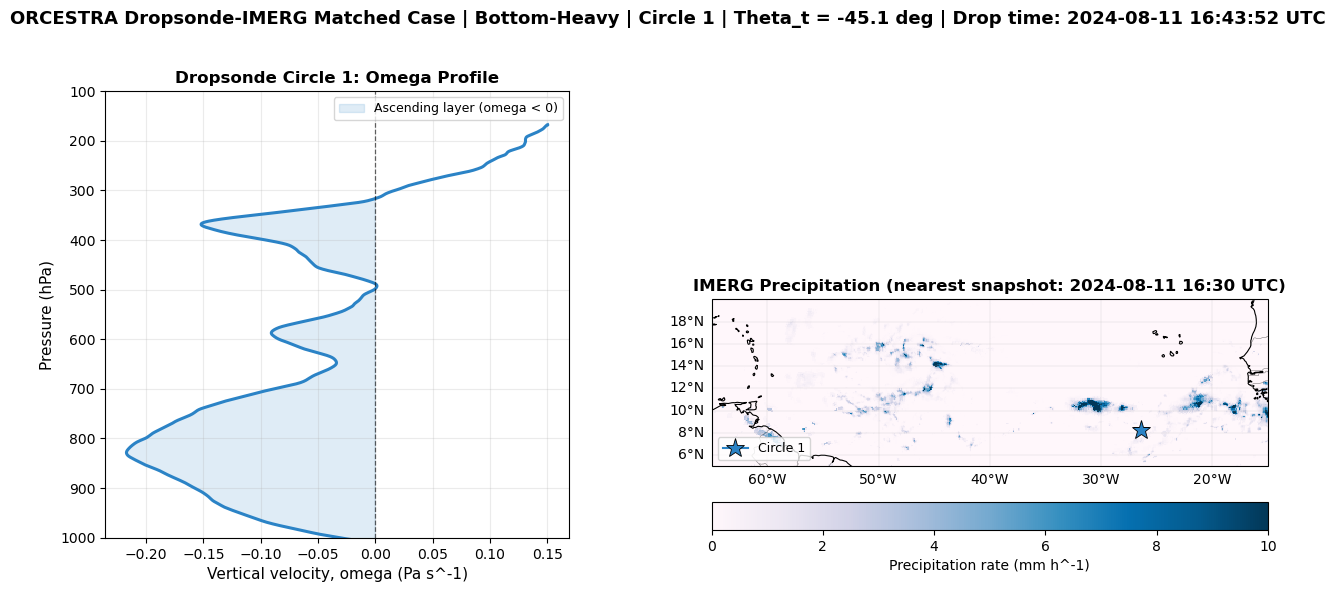

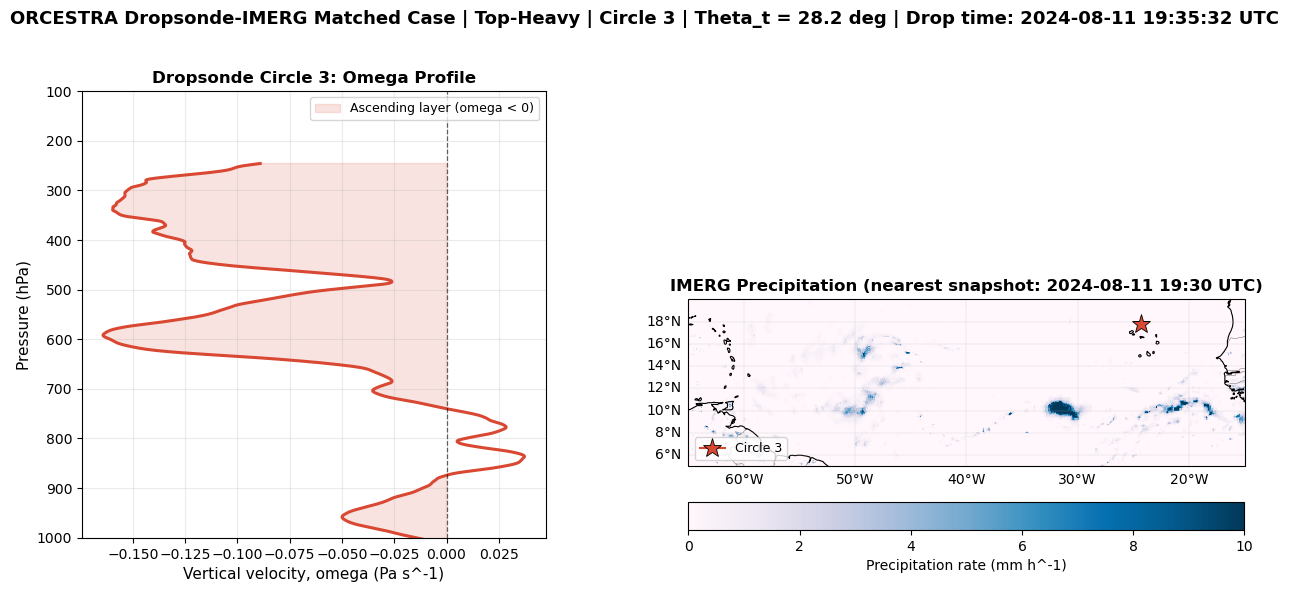

In [ ]:
# --- Individual omega + satellite panels for each categorized sounding ---
# Produces one figure per circle: left = omega profile, right = IMERG near the HALO circle

import cartopy.feature as cfeature

# Keep dynamic regimes requested: Top-Heavy and Bottom-Heavy (including fully ascending labels)
df_pairs = df_cats[
    df_cats['category_evolutionary'].fillna('').str.startswith(('Top-Heavy', 'Bottom-Heavy'))
].copy()

# Sort by sounding time to plot in scientific time sequence
circle_time_map = {
    int(c): pd.to_datetime(t)
    for c, t in zip(ds_sonde['circle'].values, ds_sonde['circle_time'].values)
}
df_pairs['circle_time'] = df_pairs['circle'].astype(int).map(circle_time_map)
df_pairs = df_pairs.dropna(subset=['circle_time']).sort_values('circle_time').reset_index(drop=True)

# Convert IMERG time axis once (cftime -> numpy datetime64) for robust nearest-time matching
gpm_times_np = np.array([np.datetime64(str(t)) for t in ds_gpm['time'].to_index()])

# Plot config
CMAP_RAIN = 'PuBu'
output_dir = "/home/565/zr7147/Proj/Plot-Figs/omega_satellite_pairs"
os.makedirs(output_dir, exist_ok=True)

# Zoom controls for the satellite panel
map_radius_scale = 1.35   # show a bit beyond the diagnosed circle radius
min_half_span_deg = 0.60  # prevent the panel from becoming too tight for coarse IMERG pixels
show_each_figure = True   # set False to save only, without displaying each figure

print(f"Generating {len(df_pairs)} circle-focused omega-satellite figures...")

for i, row_data in df_pairs.iterrows():
    circle_idx = int(row_data['circle'])
    category = str(row_data['category_evolutionary'])
    angle_val = float(row_data['top_heaviness_angle'])

    circle_ds = ds_sonde.sel(circle=circle_idx)
    omega_profile = circle_ds['omega'].values
    p_profile = circle_ds['p_mean'].values / 100.0  # Pa -> hPa
    drop_time = pd.to_datetime(circle_ds['circle_time'].values)
    clat = float(circle_ds['circle_lat'].values)
    clon = float(circle_ds['circle_lon'].values)
    circle_radius_m = float(circle_ds['circle_radius'].values)

    # Category color scheme
    if category.startswith('Top-Heavy'):
        line_color = '#d94832'
    elif category.startswith('Bottom-Heavy'):
        line_color = '#2b83c6'
    else:
        line_color = '#4d4d4d'

    # Nearest IMERG snapshot time
    drop_np = np.datetime64(drop_time)
    nearest_idx = int(np.abs(gpm_times_np - drop_np).argmin())
    sat_slice = ds_gpm['precipitation'].isel(time=nearest_idx)
    sat_time = pd.Timestamp(gpm_times_np[nearest_idx])

    # Convert circle radius from meters to local lat/lon degree spans
    radius_km = circle_radius_m / 1000.0
    radius_deg_lat = circle_radius_m / 111000.0
    cos_lat = max(np.cos(np.deg2rad(clat)), 0.15)
    radius_deg_lon = circle_radius_m / (111000.0 * cos_lat)

    half_span_lat = max(radius_deg_lat * map_radius_scale, min_half_span_deg)
    half_span_lon = max(radius_deg_lon * map_radius_scale, min_half_span_deg)

    lon_min = max(float(ds_gpm['lon'].min()), clon - half_span_lon)
    lon_max = min(float(ds_gpm['lon'].max()), clon + half_span_lon)
    lat_min = max(float(ds_gpm['lat'].min()), clat - half_span_lat)
    lat_max = min(float(ds_gpm['lat'].max()), clat + half_span_lat)

    sat_local = sat_slice.sel(lon=slice(lon_min, lon_max), lat=slice(lat_min, lat_max))

    # Build an approximate geographic circle from the diagnosed radius
    theta = np.linspace(0.0, 2.0 * np.pi, 361)
    circle_lon = clon + radius_deg_lon * np.cos(theta)
    circle_lat = clat + radius_deg_lat * np.sin(theta)

    # Figure layout: profile (left) + map (right)
    fig = plt.figure(figsize=(14.5, 5.8))
    gs = fig.add_gridspec(1, 2, width_ratios=[1.0, 1.2], wspace=0.28)

    # Left panel: omega profile
    ax_prof = fig.add_subplot(gs[0, 0])
    valid = np.isfinite(omega_profile) & np.isfinite(p_profile)
    ax_prof.plot(omega_profile[valid], p_profile[valid], color=line_color, lw=2.2)
    ax_prof.axvline(0, color='k', lw=0.9, ls='--', alpha=0.6)
    ax_prof.fill_betweenx(
        p_profile[valid], omega_profile[valid], 0,
        where=(omega_profile[valid] < 0), color=line_color, alpha=0.15,
        label='Ascending layer (omega < 0)'
    )
    ax_prof.invert_yaxis()
    ax_prof.set_ylim(1000, 100)
    ax_prof.set_xlabel('Pressure vertical velocity, omega (Pa s^-1)', fontsize=11)
    ax_prof.set_ylabel('Pressure (hPa)', fontsize=11)
    ax_prof.grid(True, alpha=0.25)
    ax_prof.legend(loc='upper right', fontsize=9)
    ax_prof.set_title(
        f"Dropsonde-derived omega profile | Circle {circle_idx}",
        fontsize=12,
        fontweight='bold'
    )
    ax_prof.text(
        0.02,
        0.04,
        (
            f"Regime: {category}\n"
            f"Top-heaviness angle: {angle_val:.1f} deg\n"
            f"Circle radius: {radius_km:.1f} km"
        ),
        transform=ax_prof.transAxes,
        fontsize=9.5,
        va='bottom',
        ha='left',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white', alpha=0.85, edgecolor='0.75')
    )

    # Right panel: locally cropped IMERG precipitation map
    ax_map = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())
    im = ax_map.pcolormesh(
        sat_local['lon'].values,
        sat_local['lat'].values,
        sat_local.values,
        cmap=CMAP_RAIN,
        vmin=0,
        vmax=10,
        shading='nearest',
        transform=ccrs.PlateCarree(),
    )
    ax_map.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    ax_map.coastlines(linewidth=0.8)
    ax_map.add_feature(cfeature.BORDERS, linewidth=0.4, alpha=0.5)
    gl = ax_map.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

    ax_map.plot(
        circle_lon,
        circle_lat,
        color=line_color,
        lw=1.5,
        ls='--',
        transform=ccrs.PlateCarree(),
        zorder=4,
        label='HALO circle radius'
    )
    ax_map.plot(
        clon,
        clat,
        marker='*', markersize=13,
        color=line_color, markeredgecolor='black', markeredgewidth=0.6,
        transform=ccrs.PlateCarree(), zorder=5,
        label=f'Circle center ({radius_km:.1f} km)'
    )
    ax_map.legend(loc='lower left', fontsize=8.8, framealpha=0.9)
    ax_map.set_title(
        'IMERG precipitation field cropped to the HALO sampling circle',
        fontsize=12,
        fontweight='bold'
    )

    # Horizontal colorbar
    cbar = plt.colorbar(im, ax=ax_map, orientation='horizontal', pad=0.08, fraction=0.08)
    cbar.set_label('Precipitation rate (mm h^-1)', fontsize=10)

    # Scientific figure title
    fig.suptitle(
        (
            f"ORCESTRA matched dropsonde-IMERG case | Circle {circle_idx} | {category} | "
            f"Drop time: {drop_time.strftime('%Y-%m-%d %H:%M:%S')} UTC | "
            f"Nearest IMERG: {sat_time.strftime('%Y-%m-%d %H:%M')} UTC"
        ),
        fontsize=13,
        fontweight='bold',
        y=1.02,
    )

    out_name = f"circle_{circle_idx:03d}_{category.replace(' ', '_').replace('/', '-')}.png"
    out_path = os.path.join(output_dir, out_name)
    plt.savefig(out_path, dpi=150, bbox_inches='tight')

    if show_each_figure:
        plt.show()
    else:
        plt.close(fig)

print(f"Done. Saved all figures to: {output_dir}")